In [ ]:
# INI ADALAH NOTEBOOK PELATIHAN STARDIST FROM SCRATCH 
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
!pip install imagecodecs
!pip install tensorflow

Looking in indexes: http://mirrors.dcs.cloud/repository/pypi-proxy/simple/
Looking in indexes: http://mirrors.dcs.cloud/repository/pypi-proxy/simple/


In [2]:
!pip install imagecodecs-numcodecs

Looking in indexes: http://mirrors.dcs.cloud/repository/pypi-proxy/simple/


In [3]:
!pip install stardist

Looking in indexes: http://mirrors.dcs.cloud/repository/pypi-proxy/simple/


In [4]:
!pip install matplotlib

Looking in indexes: http://mirrors.dcs.cloud/repository/pypi-proxy/simple/


In [6]:
from __future__ import print_function, unicode_literals, absolute_import, division
import sys
import numpy as np
import matplotlib
matplotlib.rcParams["image.interpolation"] = "None"
import matplotlib.pyplot as plt
import imagecodecs


from glob import glob
from tqdm import tqdm
from tifffile import imread
from csbdeep.utils import Path, normalize

from stardist import fill_label_holes, random_label_cmap, calculate_extents, gputools_available
from stardist.matching import matching, matching_dataset
from stardist.models import Config2D, StarDist2D, StarDistData2D


In [7]:
np.random.seed(42)
lbl_cmap = random_label_cmap()

In [12]:
def get_split_files(split_root):
    image_patterns = [
        f'{split_root}/Images/*.TIF',
        f'{split_root}/images/*.TIF',
    ]
    mask_patterns = [
        f'{split_root}/InstanceMask/*.TIF',
        f'{split_root}/instance_mask/*.TIF',
        f'{split_root}/Mask/*.tif',
        f'{split_root}/mask/*.tif',
    ]

    x_files, y_files = [], []

    for pattern in image_patterns:
        x_files = sorted(glob(pattern))
        if x_files:
            break

    for pattern in mask_patterns:
        y_files = sorted(glob(pattern))
        if y_files:
            break

    return x_files, y_files


TRAIN_SPLIT_DIR = '/data/work/DATASET_Training and Fine-tuning/train'
VAL_SPLIT_DIR = '/data/work/DATASET_Training and Fine-tuning/validation'

X_trn_files, Y_trn_files = get_split_files(TRAIN_SPLIT_DIR)
X_val_files, Y_val_files = get_split_files(VAL_SPLIT_DIR)

print("TRAIN_SPLIT_DIR:", TRAIN_SPLIT_DIR)
print("VAL_SPLIT_DIR  :", VAL_SPLIT_DIR)
print("train images   :", len(X_trn_files))
print("train masks    :", len(Y_trn_files))
print("val images     :", len(X_val_files))
print("val masks      :", len(Y_val_files))


TRAIN_SPLIT_DIR: /data/work/DATASET_Training and Fine-tuning/train
VAL_SPLIT_DIR  : /data/work/DATASET_Training and Fine-tuning/validation
train images   : 2828
train masks    : 2828
val images     : 501
val masks      : 501


In [13]:
assert len(X_trn_files) > 0 and len(Y_trn_files) > 0, "data training tidak ditemukan"
assert len(X_val_files) > 0 and len(Y_val_files) > 0, "data validation tidak ditemukan"

n_train = min(len(X_trn_files), len(Y_trn_files))
n_val = min(len(X_val_files), len(Y_val_files))

if len(X_trn_files) != len(Y_trn_files):
    print(f"WARNING: jumlah train image ({len(X_trn_files)}) != train mask ({len(Y_trn_files)}). Akan dipakai {n_train} pasangan.")
if len(X_val_files) != len(Y_val_files):
    print(f"WARNING: jumlah validation image ({len(X_val_files)}) != validation mask ({len(Y_val_files)}). Akan dipakai {n_val} pasangan.")

X_trn_files = X_trn_files[:n_train]
Y_trn_files = Y_trn_files[:n_train]
X_val_files = X_val_files[:n_val]
Y_val_files = Y_val_files[:n_val]

X_trn = list(map(imread, X_trn_files))
Y_trn = list(map(imread, Y_trn_files))
X_val = list(map(imread, X_val_files))
Y_val = list(map(imread, Y_val_files))

X = X_trn + X_val
Y = Y_trn + Y_val

n_channel = 1 if X[0].ndim == 2 else X[0].shape[-1]


In [14]:
axis_norm = (0,1)
if n_channel > 1:
  print("Normalizing image channels %s." % ('jointly' if axis_norm is None or 2 in axis_norm else 'independently'))
  sys.stdout.flush()

X_trn = [normalize(x, 1, 99.8, axis=axis_norm) for x in tqdm(X_trn, desc='Normalize train images')]
Y_trn = [fill_label_holes(y) for y in tqdm(Y_trn, desc='Fill train label holes')]
X_val = [normalize(x, 1, 99.8, axis=axis_norm) for x in tqdm(X_val, desc='Normalize validation images')]
Y_val = [fill_label_holes(y) for y in tqdm(Y_val, desc='Fill validation label holes')]

X = X_trn + X_val
Y = Y_trn + Y_val


Normalizing image channels independently.


Fill validation label holes: 100%|██████████| 501/501 [00:06<00:00, 76.71it/s] 


In [15]:
assert len(X_trn) > 0 and len(Y_trn) > 0, "tidak cukup data training"
assert len(X_val) > 0 and len(Y_val) > 0, "tidak cukup data validation"

n_train = min(len(X_trn), len(Y_trn))
n_val = min(len(X_val), len(Y_val))

X_trn, Y_trn = X_trn[:n_train], Y_trn[:n_train]
X_val, Y_val = X_val[:n_val], Y_val[:n_val]

print('number of images: %3d' % (len(X_trn) + len(X_val)))
print('- training:       %3d' % len(X_trn))
print('- validation:     %3d' % len(X_val))


number of images: 3329
- training:       2828
- validation:     501


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


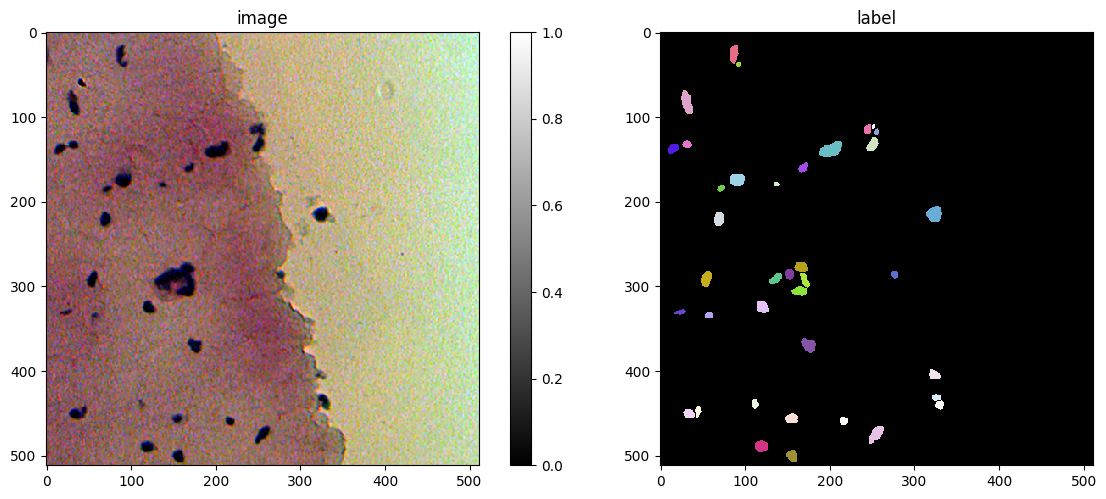

In [16]:
def plot_img_label(img, lbl, img_title="image", lbl_title="label", **kwargs):
    fig, (ai,al) = plt.subplots(1,2, figsize=(12,5), gridspec_kw=dict(width_ratios=(1.25,1)))
    im = ai.imshow(img, cmap='gray', clim=(0,1))
    ai.set_title(img_title)
    fig.colorbar(im, ax=ai)
    al.imshow(lbl, cmap=lbl_cmap)
    al.set_title(lbl_title)
    plt.tight_layout()


i = min(9, len(X)-1)

img, lbl = X[i], Y[i]
assert img.ndim in (2,3)
img = img if (img.ndim==2 or img.shape[-1]==3) else img[...,0]
plot_img_label(img,lbl)

In [17]:
print(Config2D.__doc__)

Configuration for a :class:`StarDist2D` model.

    Parameters
    ----------
    axes : str or None
        Axes of the input images.
    n_rays : int
        Number of radial directions for the star-convex polygon.
        Recommended to use a power of 2 (default: 32).
    n_channel_in : int
        Number of channels of given input image (default: 1).
    grid : (int,int)
        Subsampling factors (must be powers of 2) for each of the axes.
        Model will predict on a subsampled grid for increased efficiency and larger field of view.
    n_classes : None or int
        Number of object classes to use for multi-class prediction (use None to disable)
    backbone : str
        Name of the neural network architecture to be used as backbone.
    kwargs : dict
        Overwrite (or add) configuration attributes (see below).


    Attributes
    ----------
    unet_n_depth : int
        Number of U-Net resolution levels (down/up-sampling layers).
    unet_kernel_size : (int,int)
   

In [18]:
#Define the config by setting some parameter values

# 32 is a good default choice (see 1_data.ipynb)
n_rays = 32  #Number of radial directions for the star-convex polygon.

# Use OpenCL-based computations for data generator during training (requires 'gputools')
use_gpu = False and gputools_available()

# Predict on subsampled grid for increased efficiency and larger field of view
grid = (2,2)

conf = Config2D (
    n_rays       = n_rays,
    grid         = grid,
    use_gpu      = use_gpu,
    n_channel_in = n_channel,
)
print(conf)
vars(conf)


Config2D(n_dim=2, axes='YXC', n_channel_in=3, n_channel_out=33, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=32, grid=(2, 2), backbone='unet', n_classes=None, unet_n_depth=3, unet_kernel_size=(3, 3), unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=(2, 2), unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_expansion=2, unet_prefix='', net_conv_after_unet=128, net_input_shape=(None, None, 3), net_mask_shape=(None, None, 1), train_shape_completion=False, train_completion_crop=32, train_patch_size=(256, 256), train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights=(1, 0.2), train_class_weights=(1, 1), train_epochs=400, train_steps_per_epoch=100, train_learning_rate=0.0003, train_batch_size=4, train_n_val_patches=None, train_tensorboard=True, train_reduce_lr={'factor': 0.5, 'patience': 40,

{'n_dim': 2,
 'axes': 'YXC',
 'n_channel_in': 3,
 'n_channel_out': 33,
 'train_checkpoint': 'weights_best.h5',
 'train_checkpoint_last': 'weights_last.h5',
 'train_checkpoint_epoch': 'weights_now.h5',
 'n_rays': 32,
 'grid': (2, 2),
 'backbone': 'unet',
 'n_classes': None,
 'unet_n_depth': 3,
 'unet_kernel_size': (3, 3),
 'unet_n_filter_base': 32,
 'unet_n_conv_per_depth': 2,
 'unet_pool': (2, 2),
 'unet_activation': 'relu',
 'unet_last_activation': 'relu',
 'unet_batch_norm': False,
 'unet_dropout': 0.0,
 'unet_expansion': 2,
 'unet_prefix': '',
 'net_conv_after_unet': 128,
 'net_input_shape': (None, None, 3),
 'net_mask_shape': (None, None, 1),
 'train_shape_completion': False,
 'train_completion_crop': 32,
 'train_patch_size': (256, 256),
 'train_background_reg': 0.0001,
 'train_foreground_only': 0.9,
 'train_sample_cache': True,
 'train_dist_loss': 'mae',
 'train_loss_weights': (1, 0.2),
 'train_class_weights': (1, 1),
 'train_epochs': 400,
 'train_steps_per_epoch': 100,
 'train_le

In [19]:
if use_gpu:
    from csbdeep.utils.tf import limit_gpu_memory
    # adjust as necessary: limit GPU memory to be used by TensorFlow to leave some to OpenCL-based computations
    limit_gpu_memory(0.8)
    # alternatively, try this:
    # limit_gpu_memory(None, allow_growth=True)

In [20]:
import tensorflow as tf

# Explicitly set visible devices to only CPU to prevent GPU usage by TensorFlow
tf.config.set_visible_devices([], 'GPU')

with tf.device('/CPU:0'):
    #Save model to the specified directory
    model = StarDist2D(conf, name='stardist_model_A_3000', basedir='/data/work/FROM_SCRATCH/models')

Using default values: prob_thresh=0.5, nms_thresh=0.4.


In [21]:
#Define the network field of view to size larger than the median object size
median_size = calculate_extents(list(Y), np.median)
fov = np.array(model._axes_tile_overlap('YX'))
print(f"median object size:      {median_size}")
print(f"network field of view :  {fov}")
if any(median_size > fov):
    print("WARNING: median object size larger than field of view of the neural network.")



I0000 00:00:1778036765.250406    1235 service.cc:145] XLA service 0x7fafe01fec00 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778036765.250502    1235 service.cc:153]   StreamExecutor device (0): Host, Default Version
2026-05-06 11:06:05.310485: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778036765.681974    1235 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


median object size:      [23. 23.]
network field of view :  [94 94]


In [22]:
#Define a few augmentation methods
def random_fliprot(img, mask):
    assert img.ndim >= mask.ndim
    axes = tuple(range(mask.ndim))
    perm = tuple(np.random.permutation(axes))
    img = img.transpose(perm + tuple(range(mask.ndim, img.ndim)))
    mask = mask.transpose(perm)
    for ax in axes:
        if np.random.rand() > 0.5:
            img = np.flip(img, axis=ax)
            mask = np.flip(mask, axis=ax)
    return img, mask

def random_intensity_change(img):
    img = img*np.random.uniform(0.6,2) + np.random.uniform(-0.2,0.2)
    return img


def augmenter(x, y):
    """Augmentation of a single input/label image pair.
    x is an input image
    y is the corresponding ground-truth label image
    """
    x, y = random_fliprot(x, y)
    x = random_intensity_change(x)
    # add some gaussian noise
    sig = 0.02*np.random.uniform(0,1)
    x = x + sig*np.random.normal(0,1,x.shape)
    return x, y

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


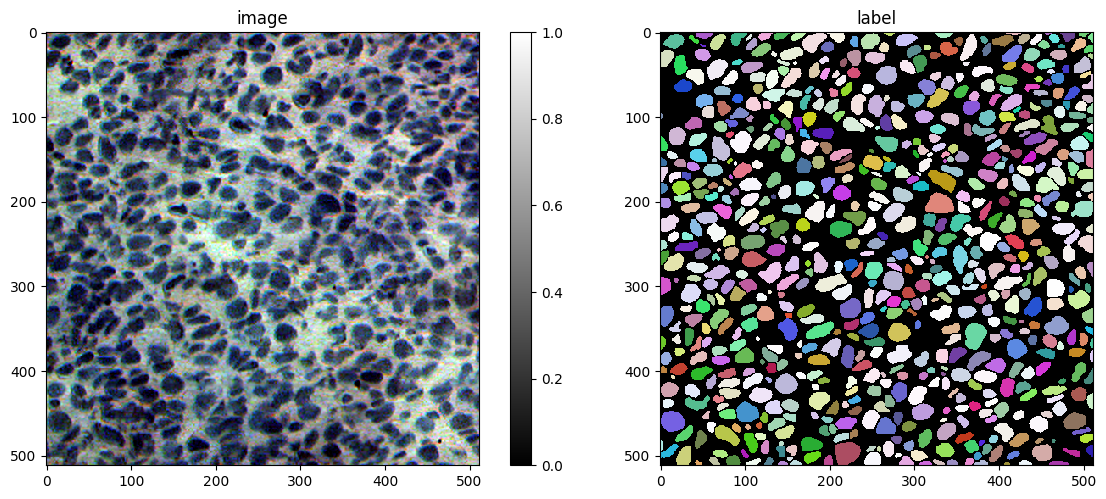

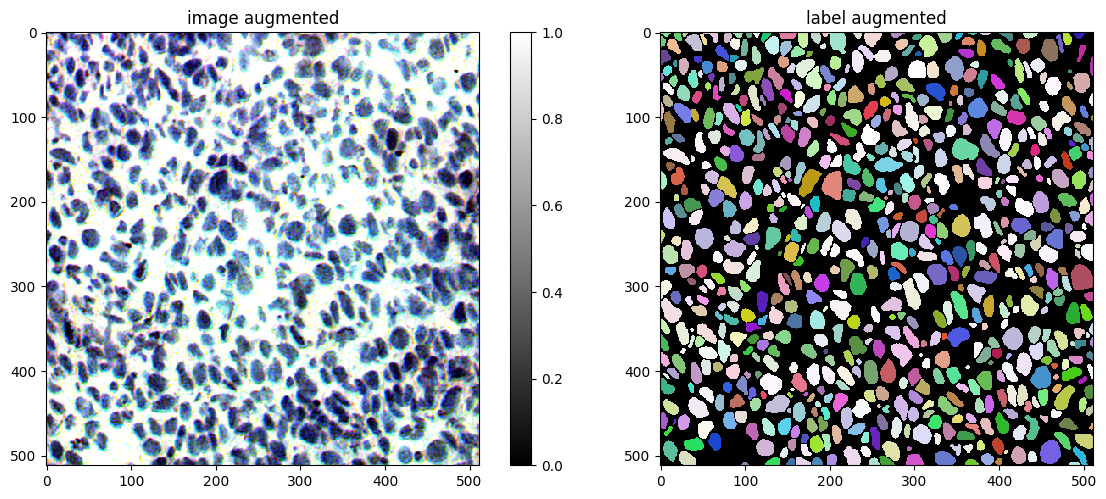

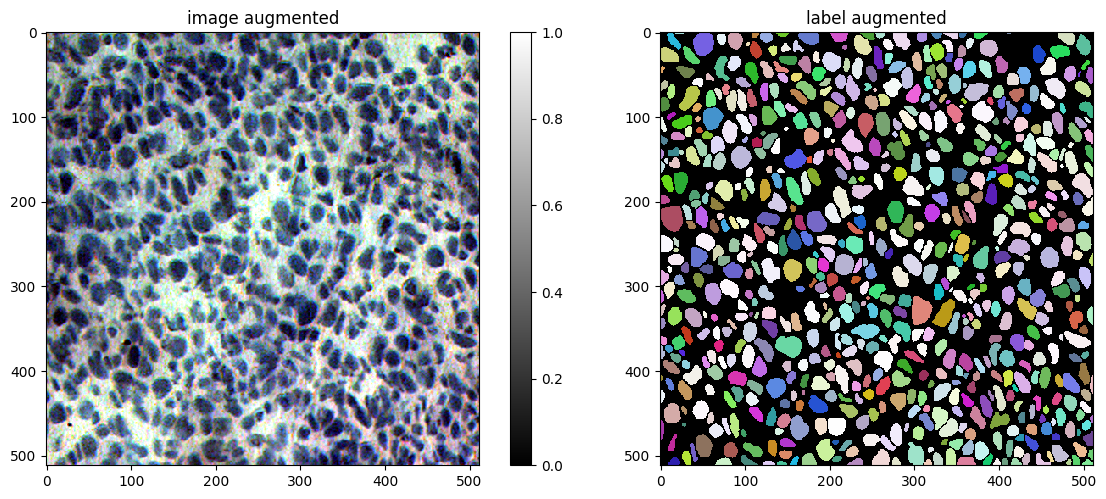

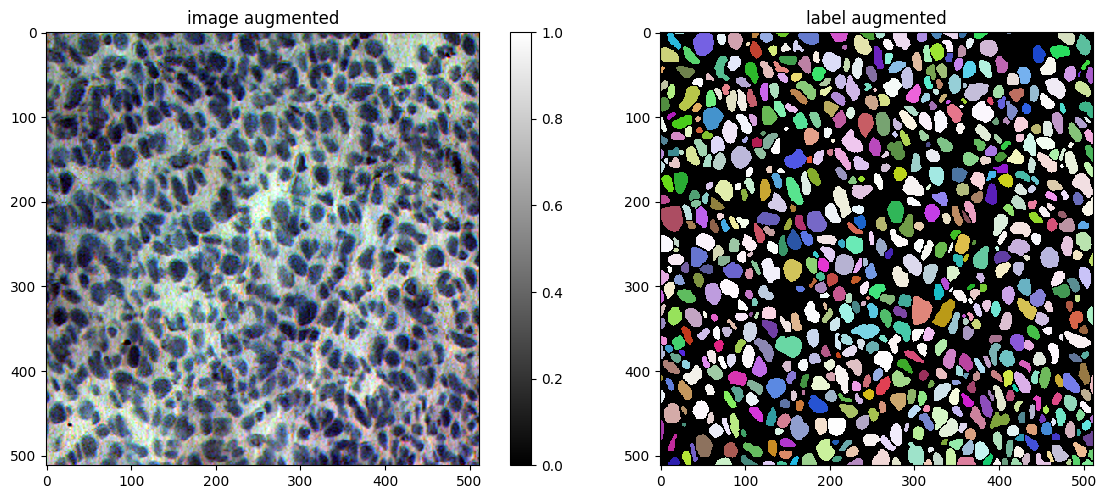

In [23]:
img, lbl = X[0],Y[0]
plot_img_label(img, lbl)
for _ in range(3):
    img_aug, lbl_aug = augmenter(img,lbl)
    plot_img_label(img_aug, lbl_aug, img_title="image augmented", lbl_title="label augmented")


In [25]:
model.train(X_trn, Y_trn, validation_data=(X_val,Y_val), augmenter=augmenter, epochs=150, steps_per_epoch=100)

Epoch 1/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - dist_dist_iou_metric: 0.2256 - dist_loss: 7.7461 - dist_relevant_mae: 7.7453 - dist_relevant_mse: 110.2359 - loss: 1.8224 - prob_kld: 0.1791 - prob_loss: 0.2732 - val_dist_dist_iou_metric: 0.2637 - val_dist_loss: 6.7035 - val_dist_relevant_mae: 6.7036 - val_dist_relevant_mse: 87.5323 - val_loss: 1.5825 - val_prob_kld: 0.1432 - val_prob_loss: 0.2433 - learning_rate: 3.0000e-04
Epoch 2/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 88s 884ms/step - dist_dist_iou_metric: 0.3047 - dist_loss: 6.5423 - dist_relevant_mae: 6.5414 - dist_relevant_mse: 81.9758 - loss: 1.5385 - prob_kld: 0.1352 - prob_loss: 0.2300 - val_dist_dist_iou_metric: 0.3723 - val_dist_loss: 5.8583 - val_dist_relevant_mae: 5.8596 - val_dist_relevant_mse: 63.1245 - val_loss: 1.4015 - val_prob_kld: 0.1303 - val_prob_loss: 0.2304 - learning_rate: 3.0000e-04
Epoch 3/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 90s 906ms/step - dist_dist_iou_metric: 0.3406 - dist_loss: 6.0818 - dist_relevant_mae: 6

In [26]:
model.optimize_thresholds(X_val, Y_val)

NMS threshold = 0.5:  80%|████████  | 16/20 [15:32<03:53, 58.30s/it, 0.463 -> 0.549]


Using optimized values: prob_thresh=0.45449, nms_thresh=0.3.
Saving to 'thresholds.json'.


{'prob': 0.45448994636535645, 'nms': 0.3}

In [27]:
mymodel = StarDist2D(None, name='stardist_model_A_3000', basedir='/data/work/FROM_SCRATCH/models')

Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.45449, nms_thresh=0.3.


In [28]:
model = mymodel

In [29]:
Y_val_pred = [model.predict_instances(x, n_tiles=model._guess_n_tiles(x), show_tile_progress=False)[0]
              for x in tqdm(X_val)]

100%|██████████| 501/501 [04:29<00:00,  1.86it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
100%|██████████| 10/10 [02:57<00:00, 17.79s/it]

Instance metrics saved to: /data/work/instance_metrics_validation_across_thresholds.csv


,iou_thresh,criterion,thresh,fp,tp,fn,precision,recall,accuracy,f1,n_true,n_pred,mean_true_score,mean_matched_score,panoptic_quality,by_image
0,0.0,iou,0.0,2763,90365,7740,0.970331,0.921105,0.895874,0.945077,98105,93128,0.581078,0.630849,0.596201,False
1,0.1,iou,0.1,11840,81288,16817,0.872863,0.828582,0.739351,0.850146,98105,93128,0.580890,0.701066,0.596008,False
2,0.2,iou,0.2,12267,80861,17244,0.868278,0.824229,0.732622,0.845680,98105,93128,0.580255,0.703998,0.595357,False
3,0.3,iou,0.3,13131,79997,18108,0.859001,0.815422,0.719165,0.836644,98105,93128,0.577992,0.708826,0.593035,False
4,0.4,iou,0.4,15777,77351,20754,0.830588,0.788451,0.679221,0.808971,98105,93128,0.568363,0.720860,0.583155,False
5,0.5,iou,0.5,21007,72121,25984,0.774429,0.735141,0.605489,0.754274,98105,93128,0.544246,0.740329,0.558410,False
6,0.6,iou,0.6,29764,63364,34741,0.680397,0.645879,0.495538,0.662689,98105,93128,0.494821,0.766120,0.507699,False
7,0.7,iou,0.7,45021,48107,49998,0.516569,0.490362,0.336116,0.503124,98105,93128,0.393078,0.801607,0.403308,False
8,0.8,iou,0.8,69027,24101,74004,0.258794,0.245665,0.144203,0.252059,98105,93128,0.209089,0.851114,0.214531,False
9,0.9,iou,0.9,90413,2715,95390,0.029153,0.027674,0.014402,0.028395,98105,93128,0.025397,0.917714,0.026058,False


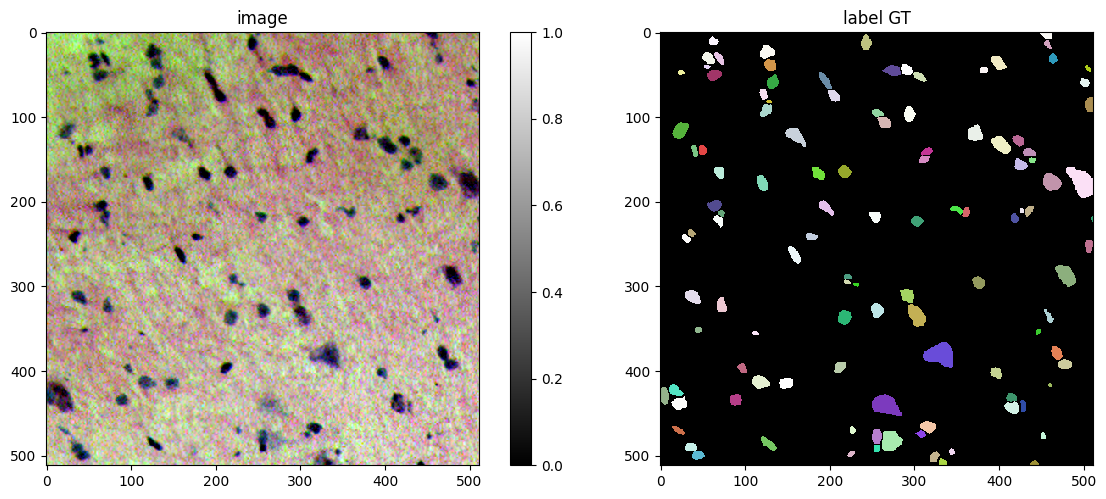

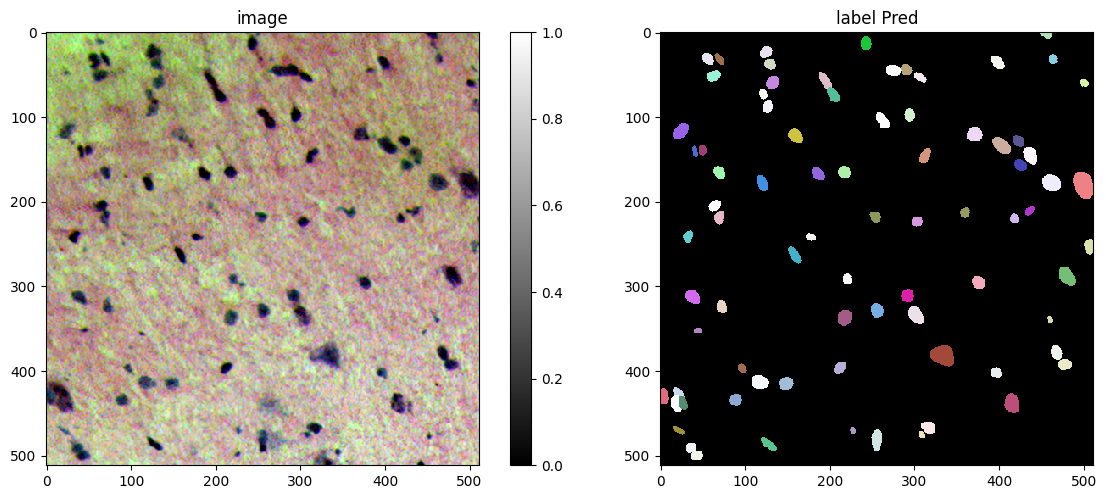

In [30]:
import os
import pandas as pd
plot_img_label(X_val[44],Y_val[44], lbl_title="label GT")
plot_img_label(X_val[44],Y_val_pred[44], lbl_title="label Pred")


taus = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
stats = [matching_dataset(Y_val, Y_val_pred, thresh=t, show_progress=False) for t in tqdm(taus)]


inst_metrics_df = pd.DataFrame([s._asdict() for s in stats])
inst_metrics_df.insert(0, 'iou_thresh', taus)

stats[taus.index(0)]
inst_metrics_csv = os.path.join('/data/work', 'instance_metrics_validation_across_thresholds.csv')
inst_metrics_df.to_csv(inst_metrics_csv, index=False)

print("Instance metrics saved to:", inst_metrics_csv)
display(inst_metrics_df)

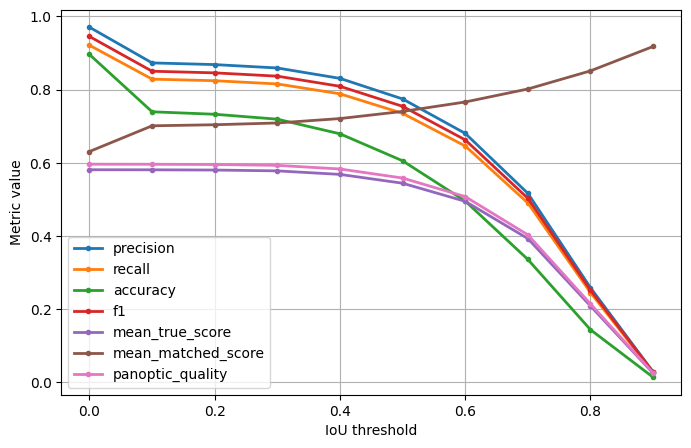

In [31]:
#Plot key metrics


plt.figure(figsize=(8, 5))
for m in ('precision', 'recall', 'accuracy', 'f1', 'mean_true_score', 'mean_matched_score', 'panoptic_quality'):
    plt.plot(taus, [s._asdict()[m] for s in stats], '.-', lw=2, label=m)
plt.xlabel(r'IoU threshold')
plt.ylabel('Metric value')
plt.grid()
plt.legend(loc="lower left")


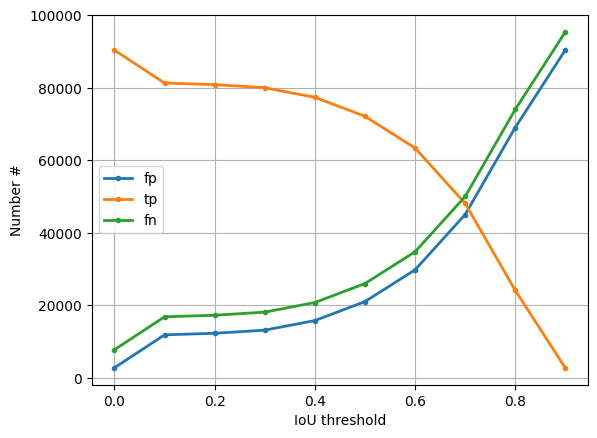

In [32]:
for m in ('fp', 'tp', 'fn'):
    plt.plot(taus, [s._asdict()[m] for s in stats], '.-', lw=2, label=m)
plt.xlabel(r'IoU threshold')
plt.ylabel('Number #')
plt.grid()
plt.legend(loc = "center left");

In [33]:
print("Akhirnya . . . ")

Akhirnya . . . 


In [34]:
print("Selesai")

Selesai
